In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose 

from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

from statsmodels.tsa.statespace.sarimax import SARIMAX 

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [66]:
df = pd.read_csv('monthly_sales.csv')

In [67]:
df.head()

,Date,Sales
0,2020-01-31,120
1,2020-02-29,118
2,2020-03-31,125
3,2020-04-30,132
4,2020-05-31,138


In [68]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

df.head()

,Sales
Date,
2020-01-31,120
2020-02-29,118
2020-03-31,125
2020-04-30,132
2020-05-31,138


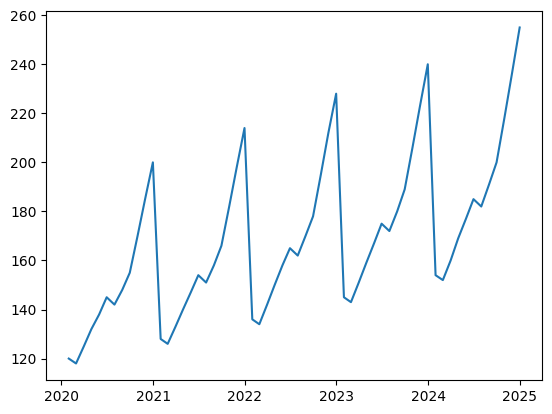

In [69]:
plt.plot(df['Sales'])

plt.show()

Rolling Statistics

In [70]:
rolling_mean = df['Sales'].rolling(window=12).mean()
rolling_std = df['Sales'].rolling(window=12).std()

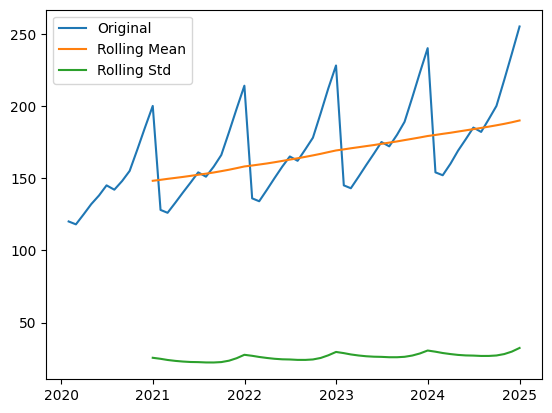

In [71]:
plt.plot(df['Sales'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')

plt.legend()
plt.show()

### Seasonal Decompose

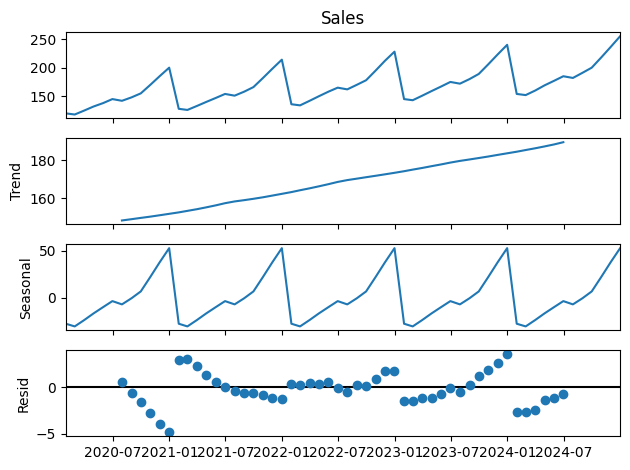

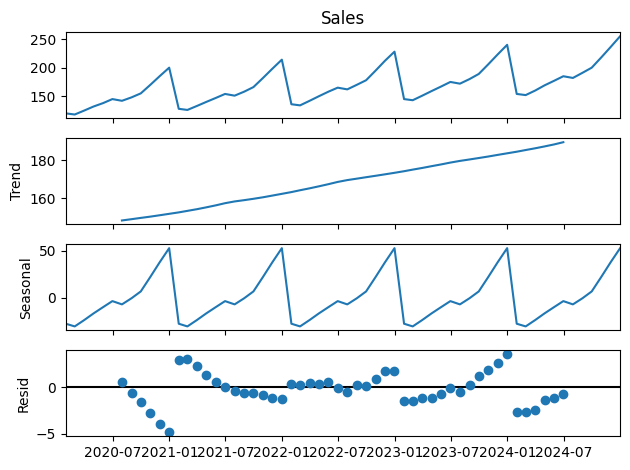

In [72]:
result = seasonal_decompose(
    df['Sales'], model='additive', period=12
)

result.plot()

### ADF Test

In [73]:
result = adfuller(df['Sales'])

print(result[1])

0.9964807106828965


In [82]:
df['Seasonal_diff'] = df['Sales'].diff(12)

result = adfuller(df['Seasonal_diff'].dropna())
print(result[1])

0.1239088800991805


In [84]:
df['Seasonal_Regular_diff'] = df['Seasonal_diff'].diff()

result = adfuller(df['Seasonal_Regular_diff'].dropna())

print(result[1])

1.096029224509102e-06


In [85]:
if result[1] < 0.05:
    print('Stationary')
else:
    print('Non-Stationary')

Stationary


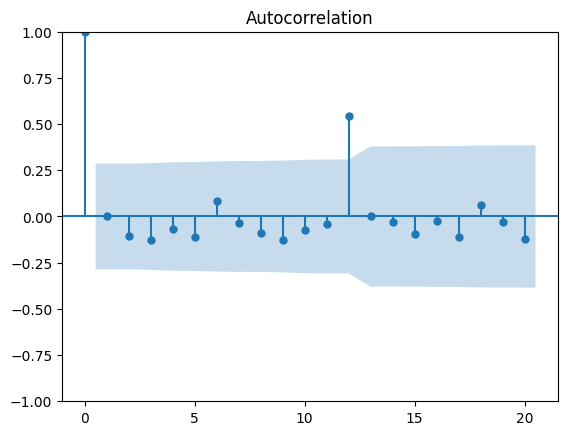

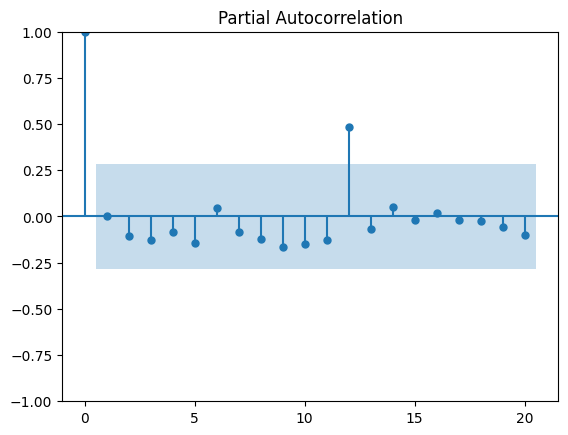

In [89]:
plot_acf(df['Seasonal_Regular_diff'].dropna(), lags=20)
plot_pacf(df['Seasonal_Regular_diff'].dropna(), lags=20)

plt.show()

### Train/Test Split



In [90]:
train = df.iloc[:-12]
test = df.iloc[-12:]

### Build SARIMA

In [91]:
model = SARIMAX(train['Sales'], order=(1,1,1), seasonal_order=(1,1,1,12))

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [92]:
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [93]:
forecast = model_fit.forecast(steps=12)

In [94]:
comparison = pd.DataFrame({
    'Actual':test['Sales'],
    "Forecast":forecast
})
comparison

,Actual,Forecast
2024-01-31,154,152.053749
2024-02-29,152,150.234409
2024-03-31,160,158.699916
2024-04-30,169,167.142899
2024-05-31,177,175.851902
2024-06-30,185,184.311095
2024-07-31,182,181.392612
2024-08-31,191,190.058168
2024-09-30,200,199.765203
2024-10-31,218,217.410641


In [95]:
mae = mean_absolute_error(test['Sales'], forecast)
rmse = np.sqrt(mean_squared_error(test['Sales'], forecast))

print(mae)
print(rmse)

1.1917786220925137
1.340212707014453


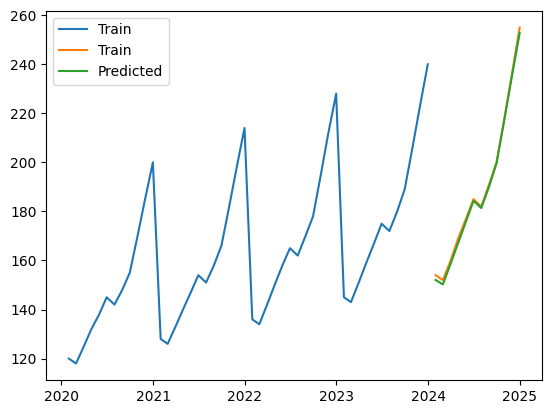

In [96]:
plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Train')
plt.plot(test.index, forecast, label='Predicted')

plt.legend()
plt.show()

In [97]:
future = model_fit.forecast(steps=12)
future

2024-01-31    152.053749
2024-02-29    150.234409
2024-03-31    158.699916
2024-04-30    167.142899
2024-05-31    175.851902
2024-06-30    184.311095
2024-07-31    181.392612
2024-08-31    190.058168
2024-09-30    199.765203
2024-10-31    217.410641
2024-11-30    235.047892
2024-12-31    252.730171
Freq: ME, Name: predicted_mean, dtype: float64